## Subsurface Lithology Prediction for Horizontal Drilling

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("geology_drilling.csv")
df.head()

,depth_m,gamma_ray,resistivity,porosity,density,rop,wob,rpm,lithology,lithology_name
0,3285.606270,72.097802,37.240751,0.268823,2.334045,22.103103,21.801874,109.299661,0,Shale
1,2953.531591,61.924991,45.027277,0.114483,2.540332,17.787619,1.193834,87.099629,1,Sandstone
2,3423.566830,71.273526,37.476102,0.180390,2.735170,11.915322,12.735003,55.248994,1,Sandstone
3,3044.667935,82.901973,27.638454,0.095184,2.455958,18.044206,1.283846,86.148334,2,Limestone
4,2354.889325,10.392735,24.668627,0.093371,2.117943,27.611613,23.595715,107.207432,2,Limestone


In [10]:
df.dropna() 
df.shape
df.columns

Index(['depth_m', 'gamma_ray', 'resistivity', 'porosity', 'density', 'rop',
       'wob', 'rpm', 'lithology', 'lithology_name'],
      dtype='object')

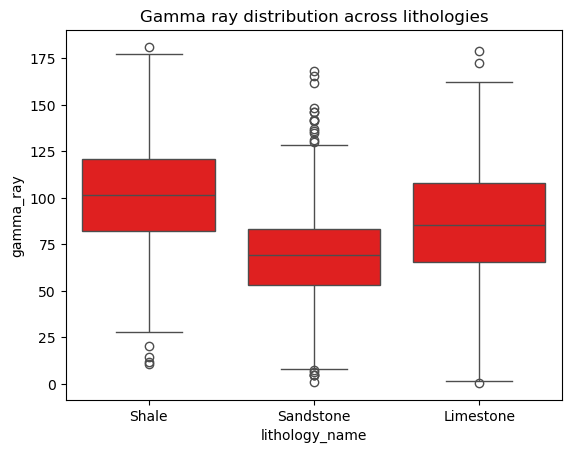

In [14]:
sns.boxplot(x="lithology_name",y="gamma_ray",data=df,color="red")
plt.title("Gamma ray distribution across lithologies")
plt.show()

In [15]:
corr = df.corr(numeric_only=True)
corr_target = corr["lithology"].sort_values(ascending=False)
print(corr_target)

lithology      1.000000
depth_m        0.255811
rop            0.020495
density       -0.001317
resistivity   -0.020044
gamma_ray     -0.204250
rpm           -0.225557
porosity      -0.233644
wob           -0.247718
Name: lithology, dtype: float64


In [16]:
x = df.drop(["lithology","lithology_name"],axis=1)
y = df["lithology"]

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [20]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

In [21]:
model.fit(x_train,y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
prediction = model.predict(x_test)

In [23]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79       208
           1       0.76      0.70      0.72       197
           2       0.73      0.82      0.77       195

    accuracy                           0.77       600
   macro avg       0.77      0.76      0.76       600
weighted avg       0.77      0.77      0.76       600



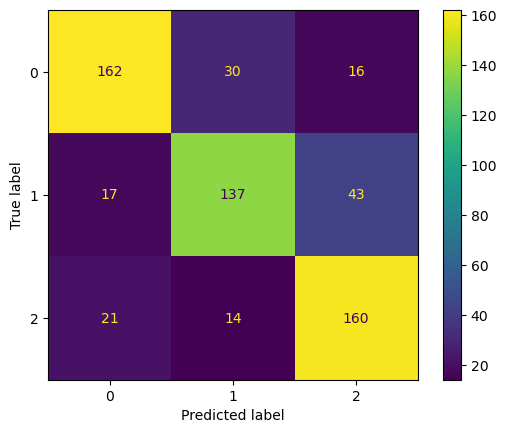

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test,prediction)

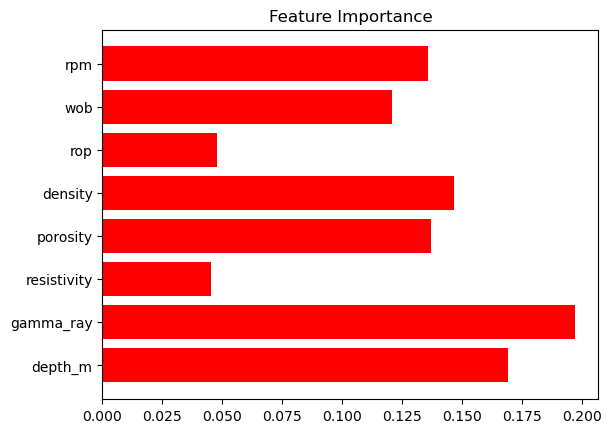

In [33]:
importance = model.feature_importances_
plt.barh(x.columns,importance,color="red")
plt.title("Feature Importance")
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test,classes=[0,1,2])
y_prob = model.predict_proba(x_test)

auc = roc_auc_score(y_test_bin,y_prob,multi_class="ovr")
print(auc,"ROC-AUC SCORE")

0.8955890052050842 ROC-AUC SCORE


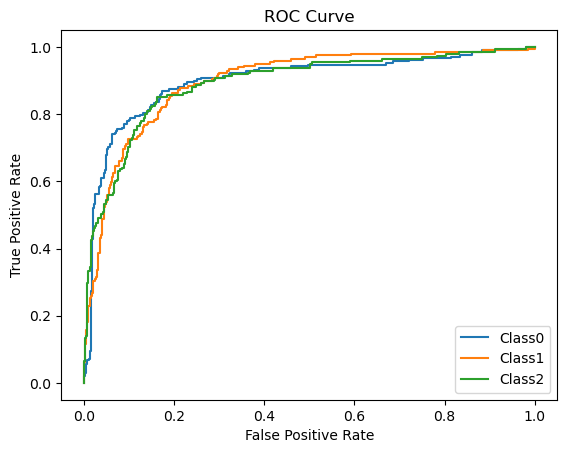

In [35]:
from sklearn.metrics import roc_curve

for i in range(3):
    fpr,tpr,_ = roc_curve(y_test_bin[:,i],y_prob[:,i])
    plt.plot(fpr,tpr,label=f"Class{i}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
    